In [1]:
# Data handling
import pandas as pd
import numpy as np

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.decomposition import PCA

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

In [2]:
from google.colab import files

uploaded = files.upload()

Saving CC_GENERAL.csv to CC_GENERAL.csv


In [3]:
df = pd.read_csv("CC_GENERAL.csv")

In [4]:
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null   float64
 11  CASH_ADVANCE_TRX                  8950 non-null   int64  
 12  PURCHA

In [6]:
df.describe()


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


In [7]:
print("Dataset shape:",df.shape)


Dataset shape: (8950, 18)


In [8]:
df.isnull().sum()
#for question 3

,0
CUST_ID,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0


In [9]:
df = df.drop("CUST_ID",axis=1)

df.head()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [10]:
df.fillna(df.mean(), inplace=True)

In [11]:
df.isnull().sum()

,0
BALANCE,0
BALANCE_FREQUENCY,0
PURCHASES,0
ONEOFF_PURCHASES,0
INSTALLMENTS_PURCHASES,0
CASH_ADVANCE,0
PURCHASES_FREQUENCY,0
ONEOFF_PURCHASES_FREQUENCY,0
PURCHASES_INSTALLMENTS_FREQUENCY,0
CASH_ADVANCE_FREQUENCY,0


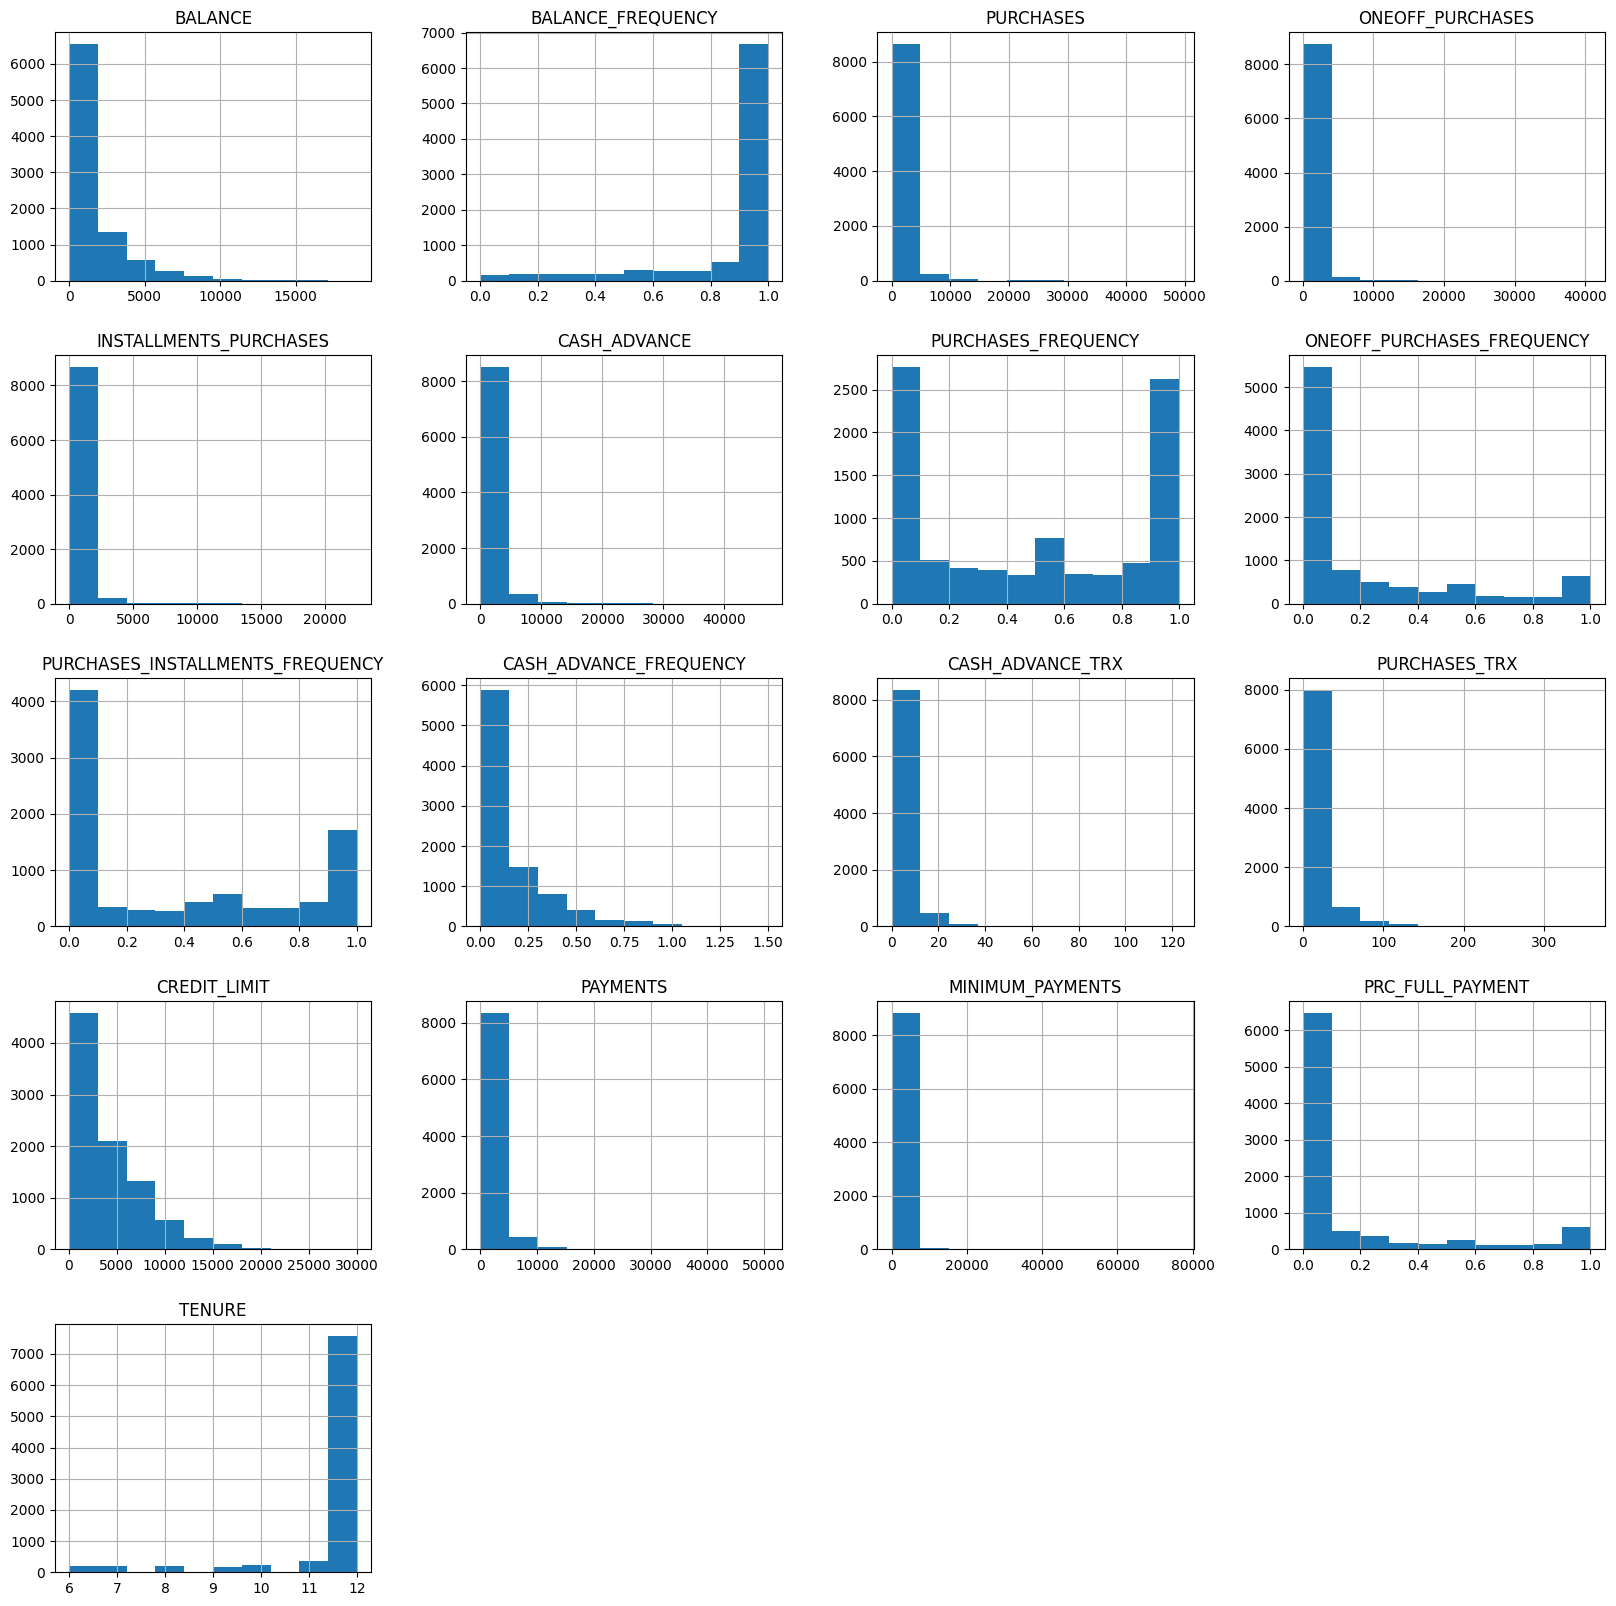

In [12]:
df.hist(figsize=(20,20))

plt.show()

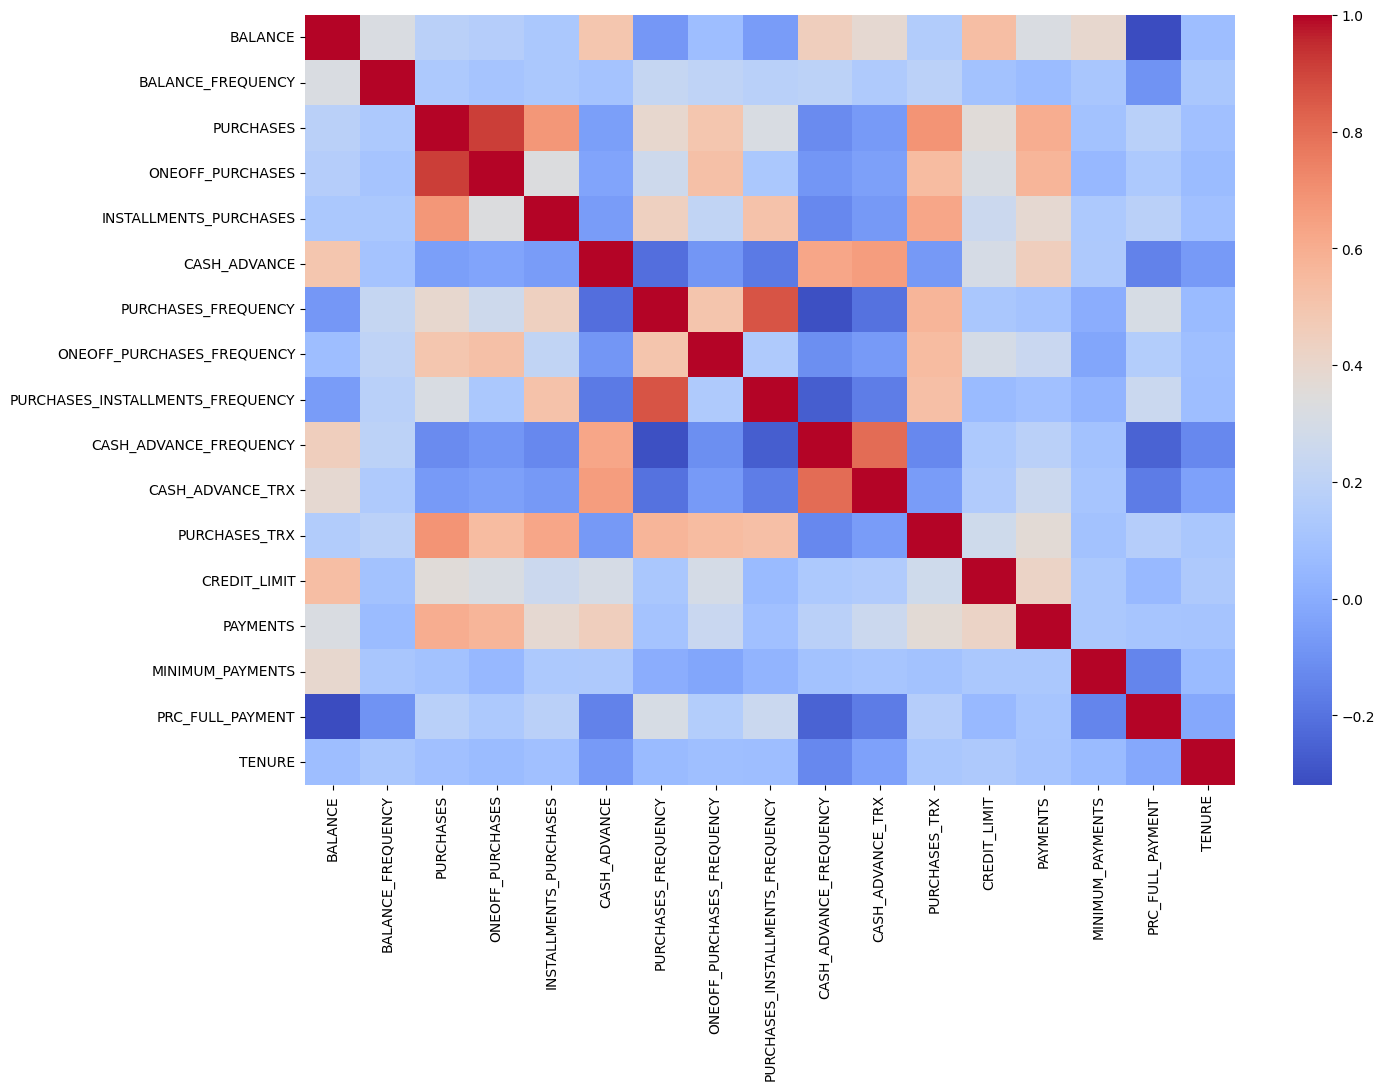

In [13]:
plt.figure(figsize=(15,10))

sns.heatmap(df.corr(),
            cmap='coolwarm')

plt.show()

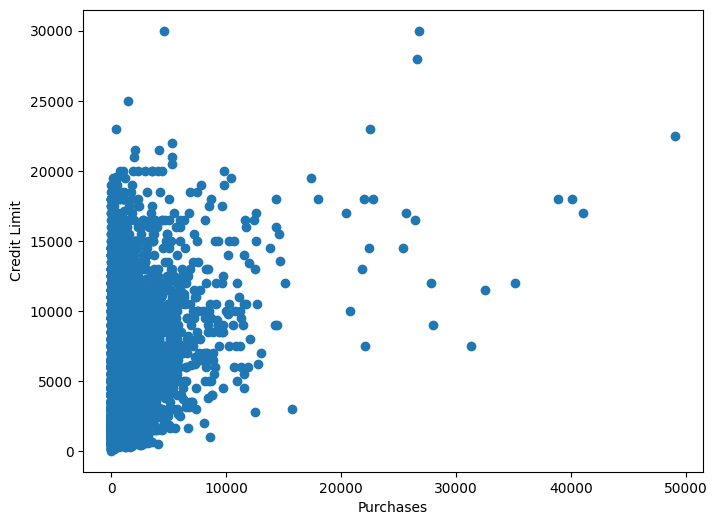

In [14]:
plt.figure(figsize=(8,6))

plt.scatter(df['PURCHASES'],
            df['CREDIT_LIMIT'])

plt.xlabel("Purchases")
plt.ylabel("Credit Limit")

plt.show()

In [15]:
scaler = StandardScaler()

scaled_data = scaler.fit_transform(df)

In [16]:
scaled_data

array([[-0.73198937, -0.24943448, -0.42489974, ..., -0.31096755,
        -0.52555097,  0.36067954],
       [ 0.78696085,  0.13432467, -0.46955188, ...,  0.08931021,
         0.2342269 ,  0.36067954],
       [ 0.44713513,  0.51808382, -0.10766823, ..., -0.10166318,
        -0.52555097,  0.36067954],
       ...,
       [-0.7403981 , -0.18547673, -0.40196519, ..., -0.33546549,
         0.32919999, -4.12276757],
       [-0.74517423, -0.18547673, -0.46955188, ..., -0.34690648,
         0.32919999, -4.12276757],
       [-0.57257511, -0.88903307,  0.04214581, ..., -0.33294642,
        -0.52555097, -4.12276757]])

In [18]:
inertia=[]

K=range(2,11)

for k in K:

    kmeans=KMeans(
        n_clusters=k,
        random_state=42
    )

    kmeans.fit(scaled_data)

    inertia.append(kmeans.inertia_)

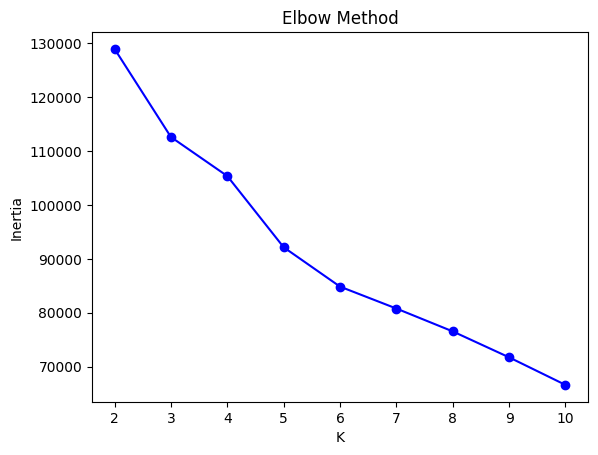

In [19]:
plt.plot(K,inertia,'bo-')

plt.xlabel("K")
plt.ylabel("Inertia")

plt.title("Elbow Method")

plt.show()

In [20]:
for k in range(2,11):

    kmeans=KMeans(
        n_clusters=k,
        random_state=42
    )

    labels=kmeans.fit_predict(
        scaled_data
    )

    score=silhouette_score(
        scaled_data,
        labels
    )

    print(
        "K=",k,
        "Score=",score
    )

K= 2 Score= 0.27991297227096823
K= 3 Score= 0.20676101192444302
K= 4 Score= 0.16639208656701637
K= 5 Score= 0.19234566924305485
K= 6 Score= 0.202755081788085
K= 7 Score= 0.19486979124151635
K= 8 Score= 0.1899728747613868
K= 9 Score= 0.2016552706516606
K= 10 Score= 0.2205181120683996


In [26]:
kmeans=KMeans(
    n_clusters=5,
    random_state=42
)

clusters = kmeans.fit_predict(
    scaled_data
)

df['Cluster']=clusters

In [27]:
df['Cluster'].value_counts()

,count
Cluster,
2,3164
3,3045
4,1357
0,989
1,395


In [31]:
cluster_summary = df.groupby(
    'Cluster'
).mean()

cluster_summary
#important

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
Cluster,,,,,,,,,,,,,,,,,
0,4901.241786,0.967162,551.983377,347.758605,204.327573,4982.037485,0.313364,0.153149,0.203718,0.507043,15.482305,8.587462,8060.469712,3853.894278,2073.175177,0.038165,11.414560
1,3588.990384,0.986874,7815.732886,5203.519089,2613.732785,661.788641,0.944730,0.740963,0.785823,0.071074,2.106329,90.351899,9769.620253,7409.095001,1991.773372,0.291103,11.949367
2,930.357741,0.962886,1299.705338,633.167216,666.735496,226.754889,0.897121,0.313579,0.719275,0.044345,0.828382,23.034766,4272.477078,1388.751132,650.399938,0.264987,11.610303
3,1524.610238,0.965721,255.629606,206.571304,49.407619,792.368773,0.159106,0.090879,0.067320,0.160476,3.035140,2.884072,3241.762452,958.334442,814.901012,0.022044,11.508046
4,111.260364,0.381755,335.222822,199.440295,136.001245,325.747598,0.281932,0.072926,0.198278,0.037617,0.788504,4.279293,3688.455338,1076.939244,264.030094,0.233951,11.270450


In [29]:
pca=PCA(n_components=2)

pca_data=pca.fit_transform(
    scaled_data
)

pca_df=pd.DataFrame(
    pca_data,
    columns=['PCA1','PCA2']
)

pca_df['Cluster']=clusters

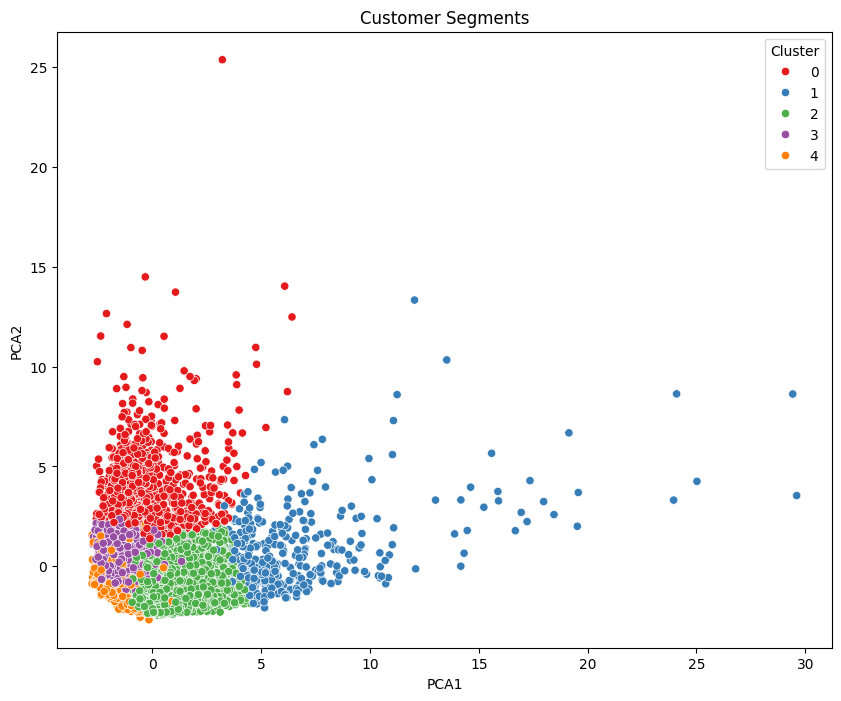

In [30]:
plt.figure(figsize=(10,8))

sns.scatterplot(
    x='PCA1',
    y='PCA2',
    hue='Cluster',
    data=pca_df,
    palette='Set1'
)

plt.title(
    "Customer Segments"
)

plt.show()

**1. Why is this an unsupervised learning problem?**

because the dataset does not contain labeled outputs or target variables. The model must discover hidden patterns and groups

**2. Why did we remove the CUST_ID column?**

dosnt contain meaningfull info for clustering

**3. Which columns had missing values?**

The columns with missing values were: MINIMUM_PAYMENTS && CREDIT_LIMIT

**4. How did you handle the missing values?**

Missing values were handled using mean imputation by replacing missing values with the average value of each column

**5. Why is scaling important before applying K-Means?**

because in K-Means Features with larger values can dominate smaller-value features and distort clustering results

**6. Which K value did you choose? Explain your answer using the elbow method and silhouette score.**

We selected K = 5 because the elbow method showed a noticeable bend around this value and the silhouette score was relatively high

**7. Based on the cluster summary table, describe each customer segment in your own words.**

0 : Customers with high balances and very high cash advance usage

1 : High-spending and highly active customers. They have the highest purchase values and purchase frequency

2 : Moderate users who make regular purchases but maintain lower balances

3 : Customers with moderate balances and low purchase activity but relatively high cash advance behavior

4 : Low-activity customers with very small balances and low spending behavior. These users rarely use their credit cards

**8. Which cluster may represent high-value customers?**

Cluster 1 : This group has the highest average PURCHASES by far (approx. 7,815), which is driven heavily by both ONEOFF_PURCHASES (~ 5,203) and INSTALLMENTS_PURCHASES (~ 2,613)

**9. Which cluster may represent customers who rely more on cash advance?**

Cluster 0 appears to rely most on cash advances, This group has an incredibly high average CASH_ADVANCE amount (~4,982) compared to all other clusters

**10. How can a company use these clusters for marketing strategy?**

A company can use these clusters to create targeted marketing strategies. High-value customers can receive loyalty rewards and premium offers, cash-advance users can be offered balance-transfer or loan options, installment-focused customers can receive installment-based promotions, and low-engagement customers can be targeted with re-engagement campaigns and cashback incentives
